# Shallow Parsing Application: Information Extraction

This notebook demonstrates how shallow parsing can be used for practical information extraction (IE).

Applications implemented:
1. Phrase-level extraction (NP, VP, PP)
2. Subject-Action-Object style tuple extraction
3. Event-style records for financial/news text
4. Aggregate IE analytics and visualization

In [1]:
from pathlib import Path
from collections import Counter
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [2]:
# Data loading and chunk label decoding
DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

CHUNK_LABELS = [
    "O", "B-ADJP", "I-ADJP", "B-ADVP", "I-ADVP", "B-CONJP", "I-CONJP", "B-INTJ", "I-INTJ", "B-LST",
    "I-LST", "B-NP", "I-NP", "B-PP", "I-PP", "B-PRT", "I-PRT", "B-SBAR", "I-SBAR", "B-UCP", "I-UCP",
    "B-VP", "I-VP"
]

def read_parquet_safe(path):
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception:
            pass
    raise RuntimeError(f"Could not read parquet file: {path}")

def decode_chunk_ids(chunk_ids):
    return [CHUNK_LABELS[int(i)] for i in chunk_ids]

train_df = read_parquet_safe(TRAIN_PATH)
test_df = read_parquet_safe(TEST_PATH)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["chunk_labels"] = train_df["chunk_tags"].apply(decode_chunk_ids)
test_df["chunk_labels"] = test_df["chunk_tags"].apply(decode_chunk_ids)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8937, 5)
Test shape: (2013, 5)


In [3]:
# BIO chunk utilities
def bio_to_spans(tokens, chunk_labels):
    spans = []
    cur_type = None
    cur_tokens = []
    cur_start = None

    for i, (tok, tag) in enumerate(zip(tokens, chunk_labels)):
        if tag == "O":
            if cur_type is not None:
                spans.append({
                    "type": cur_type,
                    "text": " ".join(cur_tokens),
                    "start": cur_start,
                    "end": i - 1,
                })
                cur_type, cur_tokens, cur_start = None, [], None
            continue

        prefix, ctype = tag.split("-", 1)

        if prefix == "B" or ctype != cur_type:
            if cur_type is not None:
                spans.append({
                    "type": cur_type,
                    "text": " ".join(cur_tokens),
                    "start": cur_start,
                    "end": i - 1,
                })
            cur_type = ctype
            cur_tokens = [tok]
            cur_start = i
        else:
            cur_tokens.append(tok)

    if cur_type is not None:
        spans.append({
            "type": cur_type,
            "text": " ".join(cur_tokens),
            "start": cur_start,
            "end": len(tokens) - 1,
        })

    return spans

def sentence_to_ie_record(tokens, chunk_labels):
    spans = bio_to_spans(tokens, chunk_labels)
    sentence = " ".join(tokens)

    nps = [s for s in spans if s["type"] == "NP"]
    vps = [s for s in spans if s["type"] == "VP"]
    pps = [s for s in spans if s["type"] == "PP"]

    subject = nps[0]["text"] if nps else None
    action = vps[0]["text"] if vps else None

    obj = None
    if vps:
        vp_end = vps[0]["end"]
        for np_span in nps:
            if np_span["start"] > vp_end:
                obj = np_span["text"]
                break

    prep_phrases = [p["text"] for p in pps]

    return {
        "sentence": sentence,
        "subject": subject,
        "action": action,
        "object": obj,
        "prep_phrases": prep_phrases,
        "num_chunks": len(spans),
    }

In [4]:
# Demo: IE records on a sample of test data
sample_n = 12
records = []
for _, row in test_df.head(sample_n).iterrows():
    rec = sentence_to_ie_record(row["tokens"], row["chunk_labels"])

    records.append(rec)

ie_sample_df = pd.DataFrame(records)
display(ie_sample_df[["sentence", "subject", "action", "object", "prep_phrases"]])

,sentence,subject,action,object,prep_phrases
0,Rockwell International Corp. 's Tulsa unit said it signed a tentative agreement extending its contract with Boeing Co. to provide structural parts for Boeing 's 747 jetliners .,Rockwell International Corp.,said,it,"[with, for]"
1,Rockwell said the agreement calls for it to supply 200 additional so-called shipsets for the planes .,Rockwell,said,the agreement,[for]
2,"These include , among other parts , each jetliner 's two major bulkheads , a pressure floor , torque box , fixed leading edges for the wings and an aft keel beam .",These,include,other parts,"[among, for]"
3,"Under the existing contract , Rockwell said , it has already delivered 793 of the shipsets to Boeing .",the existing contract,said,it,"[Under, of, to]"
4,"Rockwell , based in El Segundo , Calif. , is an aerospace , electronics , automotive and graphics concern .",Rockwell,based,El Segundo,[in]
5,"Frank Carlucci III was named to this telecommunications company 's board , filling the vacancy created by the death of William Sobey last May .",Frank Carlucci III,was named,this telecommunications company,"[to, by, of]"
6,"Mr. Carlucci , 59 years old , served as defense secretary in the Reagan administration .",Mr. Carlucci,served,defense secretary,"[as, in]"
7,"In January , he accepted the position of vice chairman of Carlyle Group , a merchant banking concern .",January,accepted,the position,"[In, of, of]"
8,SHEARSON LEHMAN HUTTON Inc .,SHEARSON LEHMAN HUTTON Inc,NaN,NaN,[]
9,"Thomas E. Meador , 42 years old , was named president and chief operating officer of Balcor Co. , a Skokie , Ill. , subsidiary of this New York investment banking firm .",Thomas E. Meador,was named,president,"[of, of]"


In [7]:
# Application 1: Event-style extraction for finance/news verbs
event_verbs = [
    "rose", "fell", "gain", "gains", "lost", "drop", "dropped",
    "acquire", "acquired", "buy", "bought", "sell", "sold",
    "announce", "announced", "expects", "expected", "increase", "decrease",
]
event_pattern = re.compile(
    r"\b(" + "|".join(map(re.escape, event_verbs)) + r")\b",
    re.IGNORECASE,
 )

event_rows = []
for _, row in test_df.iterrows():
    rec = sentence_to_ie_record(row["tokens"], row["chunk_labels"])

    text = (rec.get("action") or "") + " " + rec["sentence"]
    if event_pattern.search(text):
        event_rows.append(rec)

# Ensure stable schema even when no events are matched.
expected_cols = ["sentence", "subject", "action", "object", "prep_phrases", "num_chunks"]
events_df = pd.DataFrame(event_rows, columns=expected_cols)

print("Extracted event-like rows:", len(events_df))
if events_df.empty:
    print("No rows matched the event verb list. Try expanding `event_verbs`.")
else:
    display(events_df[["sentence", "subject", "action", "object"]].head(20))

Extracted event-like rows: 293


,sentence,subject,action,object
0,"In addition to the increased reserve , the savings bank took a special charge of $ 5 million representing general and administrative expenses from staff reductions and other matters , and it poste...",addition,took,a special charge
1,"Including Monday 's plunge , that has given the two executives paper losses of $ 49.5 million , based on what they would have realized had the pilots and management-led buy-out of UAL gone through...",Monday,has given,the two executives
2,"When bank financing for the buy-out collapsed last week , so did UAL 's stock .",bank financing,collapsed,last week
3,"Even if the banks resurrect a financing package at $ 250 a share , the two executives would still get about $ 25 million less than they stood to gain in the initial transaction .",the banks,resurrect,a financing package
4,"Mr. Wolf owns 75,000 UAL shares and has options to buy another 250,000 at $ 83.3125 each .",Mr. Wolf,owns,"75,000 UAL shares"
5,"He left his last two jobs at Republic Airlines and Flying Tiger with combined stock-option gains of about $ 22 million , and UAL gave him a $ 15 million bonus when it hired him .",He,left,his last two jobs
6,"Mr. Pope owns 10,000 UAL shares and has options to buy another 150,000 at $ 69 each .",Mr. Pope,owns,"10,000 UAL shares"
7,"That came to a combined $ 37.7 million under the $ 300-a-share buy-out , but just $ 21.3 million at yesterday 's close .",That,came,a combined $ 37.7 million
8,"Of the combined $ 114.4 million the two men were scheduled to reap under the buy-out , they agreed to invest in the buy-out just $ 15 million , angering many of the thousands of workers asked to m...",the combined $ 114.4 million,were scheduled to reap,the buy-out
9,"Conceivably , in a scaled-back buy-out , they could be bumped back to coach seats for life .",a scaled-back buy-out,could be bumped,coach seats


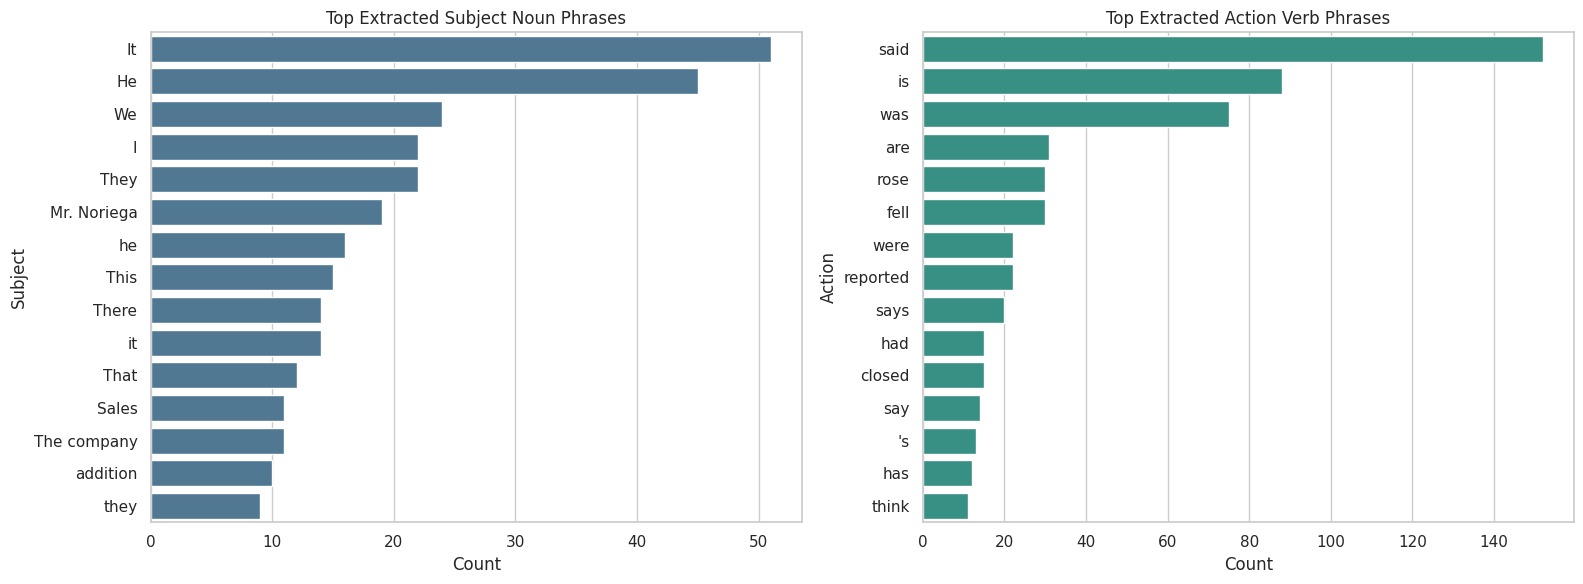

In [8]:
# Application 2: Entity/phrase analytics from extracted IE tuples
all_records = [
    sentence_to_ie_record(row["tokens"], row["chunk_labels"])

    for _, row in test_df.iterrows()
 ]
all_ie_df = pd.DataFrame(all_records)

top_subjects = all_ie_df["subject"].dropna().value_counts().head(15)
top_actions = all_ie_df["action"].dropna().value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=top_subjects.values, y=top_subjects.index, ax=axes[0], color="#457b9d")
axes[0].set_title("Top Extracted Subject Noun Phrases")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Subject")

sns.barplot(x=top_actions.values, y=top_actions.index, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Top Extracted Action Verb Phrases")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Action")

plt.tight_layout()
plt.show()

In [10]:
# Optional: Use trained transformer model from outputs for custom sentence IE
custom_text = "The company announced a major acquisition in Europe yesterday."

def pick_latest_checkpoint(base_dir: Path):
    if not base_dir.exists():
        return None

    # Prefer explicit Trainer checkpoints.
    ckpts = [
        p for p in base_dir.iterdir()
        if p.is_dir() and p.name.startswith("checkpoint-") and (p / "config.json").exists()
    ]
    if ckpts:
        return sorted(ckpts, key=lambda p: int(p.name.split("-")[-1]))[-1]

    # Fallback: use base dir if it already contains a model config.
    if (base_dir / "config.json").exists():
        return base_dir

    return None

try:
    from transformers import pipeline

    model_root = Path("outputs/distilbert-conll2000")
    model_dir = pick_latest_checkpoint(model_root)
    if model_dir is None:
        raise FileNotFoundError(
            "No valid model checkpoint found. Expected config.json in outputs/distilbert-conll2000/checkpoint-*"
        )

    print("Using model checkpoint:", model_dir)
    clf = pipeline(
        "token-classification",
        model=str(model_dir),
        tokenizer=str(model_dir),
        aggregation_strategy="none",
    )
    pred = clf(custom_text)
    pred_df = pd.DataFrame(pred)
    display(pred_df.head(30))

    print("Custom text:")
    print(custom_text)
except Exception as e:
    print("Optional transformer inference skipped.")
    print("Reason:", e)

Using model checkpoint: outputs/distilbert-conll2000/checkpoint-1677


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 8117.55it/s]


,entity,score,index,word,start,end
0,B-NP,0.998927,1,the,0,3
1,I-NP,0.998443,2,company,4,11
2,B-VP,0.997830,3,announced,12,21
3,B-NP,0.998696,4,a,22,23
4,I-NP,0.997909,5,major,24,29
5,I-NP,0.998312,6,acquisition,30,41
6,B-PP,0.998205,7,in,42,44
7,B-NP,0.998589,8,europe,45,51
8,B-NP,0.997428,9,yesterday,52,61


Custom text:
The company announced a major acquisition in Europe yesterday.


## Notes

- This notebook shows IE-style applications using shallow parsing outputs.
- For production IE, combine chunking with NER, relation extraction, and confidence filtering.
- You can replace gold chunk labels with model-predicted chunk labels to simulate real-world deployment.